In [21]:
from pathlib import Path
import numpy as np
import pandas as pd
from PIL import Image
from decimal import Decimal
import matplotlib.pyplot as plt


In [22]:
INPUT_CSV   = Path("/zpool/vladlab/active_drive/omaltz/scripts/geogaze/openimg_scripts/geogaze_task/results/predictions_cornets_identification.csv")    #individuation csv 
MODELS_ROOT = Path("/zpool/vladlab/data_drive/geogaze_data/cornetS_openimages/geogaze_task/cornets_identification")  # contains folders named by values in `model`
MASKS_ROOT  = Path("/zpool/vladlab/data_drive/geogaze_data/decoder_stimulus/test_stimuli/test_acc_masks")      # contains target/distractor mask images
OUTPUT_CSV  = Path("/zpool/vladlab/active_drive/omaltz/scripts/geogaze/openimg_scripts/geogaze_task/results/predictions_cornets_identification_pred_avg.csv")

# Column names in your master CSV
COL_MODEL      = "model"
COL_TEST_IMAGE = "test_image"
COL_TARGET     = "target"
COL_DISTRACTOR = "distractor"

DECIMAL_PLACES = 10


In [23]:
#take mask with white background black object and turn it into a binary array where white pixels are 0, black pixels are 1

def load_mask_df(img_path: str | Path) -> pd.DataFrame:
    """
    Load black/white mask image -> binary mask DataFrame (224x224):
      black object -> 1
      white background -> 0
    """
    img_path = Path(img_path)
    img = Image.open(img_path).convert("L")
    arr = np.array(img, dtype=np.uint8)

    # white -> 1, black -> 0
    bw = (arr > 127).astype(np.uint8)

    # invert so black object -> 1
    mask = 1 - bw
    return pd.DataFrame(mask)

def load_prob_map_df(csv_path: str | Path) -> pd.DataFrame:
    """
    Load probability map CSV as a DataFrame (224x224).
    Assumes it's clean and already exactly the matrix (no index col).
    """
    csv_path = Path(csv_path)
    return pd.read_csv(csv_path, header=None)

def masked_mean_df(x_df: pd.DataFrame, mask_df: pd.DataFrame) -> float:
    """
    Mean of x where mask == 1, using DataFrames.
    """
    # This creates a DataFrame with values where mask==1 and NaN elsewhere
    masked = x_df.where(mask_df == 1)
    return float(masked.stack().mean())  # stack() drops NaNs

def prob_csv_name_from_test_image(test_image: str) -> str:
    stem = Path(test_image).stem
    return f"{stem}_prob_map.csv"


In [24]:
df = pd.read_csv(INPUT_CSV)

target_means = []
distractor_means = []

for _, row in df.iterrows():
    model_folder = MODELS_ROOT / row["model"]

    prob_csv = prob_csv_name_from_test_image(row["test_image"])
    prob_map_path = model_folder / prob_csv

    target_mask_path = MASKS_ROOT / row["target"]
    distractor_mask_path = MASKS_ROOT / row["distractor"]

    x_df = load_prob_map_df(prob_map_path)
    target_mask_df = load_mask_df(target_mask_path)
    distractor_mask_df = load_mask_df(distractor_mask_path)

    target_means.append(masked_mean_df(x_df, target_mask_df))
    distractor_means.append(masked_mean_df(x_df, distractor_mask_df))

df["target_mean"] = target_means
df["distractor_mean"] = distractor_means

# Save with no scientific notation
df.to_csv(OUTPUT_CSV, index=False, float_format=f"%.{DECIMAL_PLACES}f")

OUTPUT_CSV

PosixPath('/zpool/vladlab/active_drive/omaltz/scripts/geogaze/openimg_scripts/geogaze_task/results/predictions_cornets_identification_pred_avg.csv')

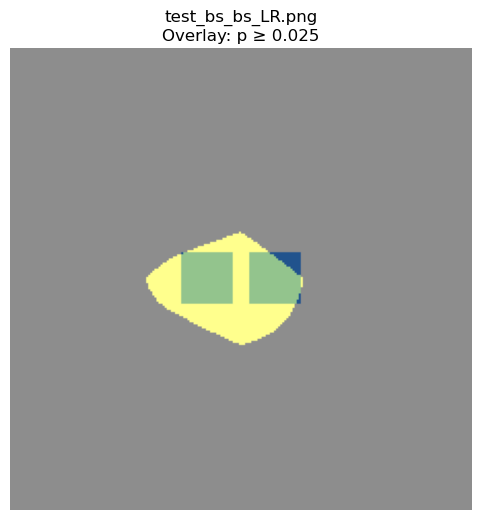

In [25]:
IMAGE_ROOT  = Path("/zpool/vladlab/data_drive/geogaze_data/decoder_stimulus/test_stimuli/test_pairs/")

ROW_IDX = 2
THRESH = 0.025  # <-- probability threshold



# Load row info
row = df.iloc[ROW_IDX]

# Original image
img_path = IMAGE_ROOT / row["test_image"]
img = Image.open(img_path).convert("RGB")
img_arr = np.array(img)

# Prediction map
model_folder = MODELS_ROOT / row["model"]
prob_csv = f"{Path(row['test_image']).stem}_prob_map.csv"
prob_map_path = model_folder / prob_csv

prob_df = pd.read_csv(prob_map_path, header=0)
prob_arr = prob_df.to_numpy()

# Threshold the prediction map
high_prob = prob_arr >= THRESH


# Build overlay 
overlay = np.zeros_like(img_arr)
overlay[..., 0] = high_prob * 255   
overlay[..., 1] = high_prob * 255   
overlay[..., 2] = 0                 


# Plot
plt.figure(figsize=(6, 6))
plt.imshow(img_arr)
plt.imshow(overlay, alpha=0.45)
plt.axis("off")
plt.title(
    f"{row['test_image']}\n"
    f"Overlay: p ≥ {THRESH}"
)
plt.show()

In [26]:
import pandas as pd
import numpy as np

# 1. Load the existing CSV
df = pd.read_csv("/zpool/vladlab/active_drive/omaltz/scripts/geogaze/openimg_scripts/geogaze_task/results/predictions_cornets_identification_pred_avg.csv")

# 2. Create the new column
denom = df["target_mean"] + df["distractor_mean"]
df["ratio"] = df["target_mean"] / denom.replace(0, np.nan)

# 3. Write it back out (overwrite or new file)

df.to_csv("/zpool/vladlab/active_drive/omaltz/scripts/geogaze/openimg_scripts/geogaze_task/results/predictions_cornets_identification_pred_avg_ratio.csv", index=False)  # safer: new file


/tmp/ipykernel_3540925/1329405452.py:43: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["dataset", "condition"])
/tmp/ipykernel_3540925/1329405452.py:66: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(


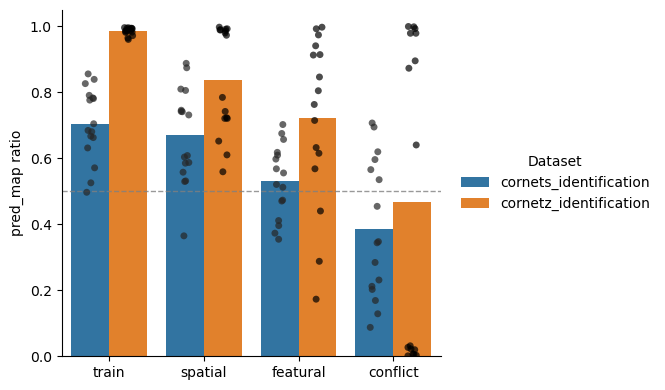

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# CONFIG
CSV_1 = "/zpool/vladlab/active_drive/omaltz/scripts/geogaze/openimg_scripts/geogaze_task/results/predictions_cornets_identification_pred_avg_ratio.csv"
CSV_2 = "/zpool/vladlab/active_drive/omaltz/scripts/geogaze/coco_decoder/v2/identification/results/geogaze_model_predictions_identification_pred_avg_ratio.csv"

COND_ORDER = ["train", "spatial", "featural", "conflict"]

# LOAD
df1 = pd.read_csv(CSV_1)
df2 = pd.read_csv(CSV_2)

df1["dataset"] = "cornets_identification"
df2["dataset"] = "cornetz_identification"

df = pd.concat([df1, df2], ignore_index=True)

COND_ORDER = ["train", "spatial", "featural", "conflict"]

# =========================
# WITHIN-MODEL COLLAPSE
# =========================
df_collapsed = (
    df
    .groupby(["dataset", "model", "condition"], as_index=False)
    .agg(ratio=("ratio", "mean"))
)

df_collapsed["condition"] = pd.Categorical(
    df_collapsed["condition"],
    categories=COND_ORDER,
    ordered=True
)

# =========================
# SUMMARY STATS (MEAN + SEM)
# =========================
summary = (
    df_collapsed
    .groupby(["dataset", "condition"])
    .agg(
        mean_ratio=("ratio", "mean"),
        sd_ratio=("ratio", "std"),
        n_models=("ratio", "count")
    )
    .reset_index()
)

summary["sem_ratio"] = summary["sd_ratio"] / np.sqrt(summary["n_models"])

plt.figure(figsize=(8, 4))

ax = sns.barplot(
    data=summary,
    x="condition",
    y="mean_ratio",
    hue="dataset",
    dodge=True,
    errorbar=None
)


sns.stripplot(
    data=df_collapsed,
    x="condition",
    y="ratio",
    hue="dataset",
    dodge=True,
    jitter=True,
    color="black",
    alpha=0.7,
    size=5,
    ax=ax
)

ax.axhline(
    y=0.5,
    linestyle="--",
    linewidth=1,
    color="gray",
    alpha=0.8
)


handles, labels = ax.get_legend_handles_labels()
n = summary["dataset"].nunique()

ax.legend(
    handles[:n],
    labels[:n],
    title="Dataset",
    frameon=False,
    loc="center left",
    bbox_to_anchor=(1.02, 0.5)   # <-- pushes legend outside
)


ax.set_ylabel("pred_map ratio")
ax.set_xlabel("")
sns.despine()

plt.tight_layout(rect=[0, 0, 0.85, 1])  # <-- leaves room for legend
plt.show()

/tmp/ipykernel_4055825/335476401.py:42: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_collapsed.groupby(["dataset", "condition"], as_index=False)
/tmp/ipykernel_4055825/335476401.py:91: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(


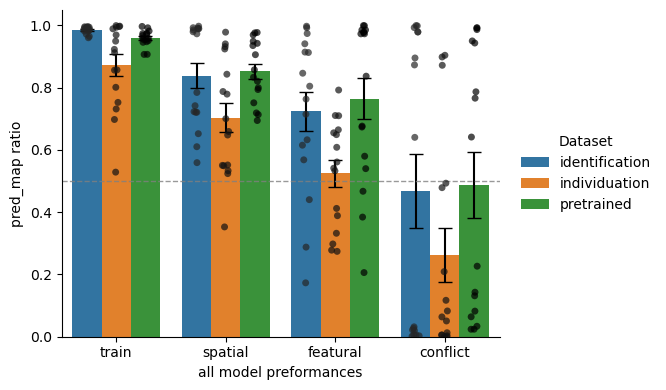

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# =========================
# CONFIG
# =========================
CSV_1 = "/zpool/vladlab/active_drive/omaltz/scripts/geogaze/coco_decoder/v2/identification/results/geogaze_model_predictions_identification_pred_avg_ratio.csv"
CSV_2 = "/zpool/vladlab/active_drive/omaltz/scripts/geogaze/coco_decoder/v2/individuation/results/geogaze_model_predictions_individuation_pred_avg_ratio.csv"
CSV_3 = "/zpool/vladlab/active_drive/omaltz/scripts/geogaze/coco_decoder/v2/pretrained/geogaze_model_predictions_pretrained_pred_avg_ratio.csv"  # <-- EDIT ME

COND_ORDER = ["train", "spatial", "featural", "conflict"]

# =========================
# LOAD
# =========================
df1 = pd.read_csv(CSV_1); df1["dataset"] = "identification"
df2 = pd.read_csv(CSV_2); df2["dataset"] = "individuation"
df3 = pd.read_csv(CSV_3); df3["dataset"] = "pretrained"  # <-- rename label if you want

df = pd.concat([df1, df2, df3], ignore_index=True)

# =========================
# WITHIN-MODEL COLLAPSE
# =========================
df_collapsed = (
    df.groupby(["dataset", "model", "condition"], as_index=False)
      .agg(ratio=("ratio", "mean"))
)

df_collapsed["condition"] = pd.Categorical(
    df_collapsed["condition"],
    categories=COND_ORDER,
    ordered=True
)

# =========================
# SUMMARY STATS (MEAN + SEM)
# =========================
summary = (
    df_collapsed.groupby(["dataset", "condition"], as_index=False)
      .agg(
          mean_ratio=("ratio", "mean"),
          sd_ratio=("ratio", "std"),
          n_models=("ratio", "count")
      )
)
summary["sem_ratio"] = summary["sd_ratio"] / np.sqrt(summary["n_models"])

# =========================
# PLOT
# =========================
plt.figure(figsize=(8, 4))
ax = sns.barplot(
    data=summary,
    x="condition",
    y="mean_ratio",
    hue="dataset",
    order=COND_ORDER,
    dodge=True,
    errorbar=None
)

# ---- SEM error bars (computed to match seaborn's dodge positions) ----
hue_order = list(summary["dataset"].dropna().unique())
n_hue = len(hue_order)

# width seaborn uses for a single bar "slot" is ~0.8 of the category width
group_width = 0.8
bar_width = group_width / max(n_hue, 1)

for _, row in summary.iterrows():
    cond_i = COND_ORDER.index(row["condition"])
    hue_i = hue_order.index(row["dataset"])

    # center bars within category slot
    x_pos = cond_i - group_width / 2 + bar_width / 2 + hue_i * bar_width

    ax.errorbar(
        x=x_pos,
        y=row["mean_ratio"],
        yerr=row["sem_ratio"],
        fmt="none",
        capsize=5,
        linewidth=1.5,
        color="black"
    )

# ---- Individual model points (black dots) ----
sns.stripplot(
    data=df_collapsed,
    x="condition",
    y="ratio",
    hue="dataset",
    order=COND_ORDER,
    dodge=True,
    jitter=True,
    color="black",
    alpha=0.7,
    size=5,
    ax=ax
)

# ---- Reference line ----
ax.axhline(y=0.5, linestyle="--", linewidth=1, color="gray", alpha=0.8)

# =========================
# LEGEND OUTSIDE (dedupe barplot + stripplot legends)
# =========================
handles, labels = ax.get_legend_handles_labels()
ax.legend(
    handles[:n_hue],
    labels[:n_hue],
    title="Dataset",
    frameon=False,
    loc="center left",
    bbox_to_anchor=(1.02, 0.5)
)

# =========================
# LABELS & CLEANUP
# =========================
ax.set_ylabel("pred_map ratio")
ax.set_xlabel("all model preformances")
sns.despine()
plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.show()


/tmp/ipykernel_4055825/2229562250.py:41: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_collapsed.groupby(["dataset", "condition"], as_index=False)
/tmp/ipykernel_4055825/2229562250.py:90: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(


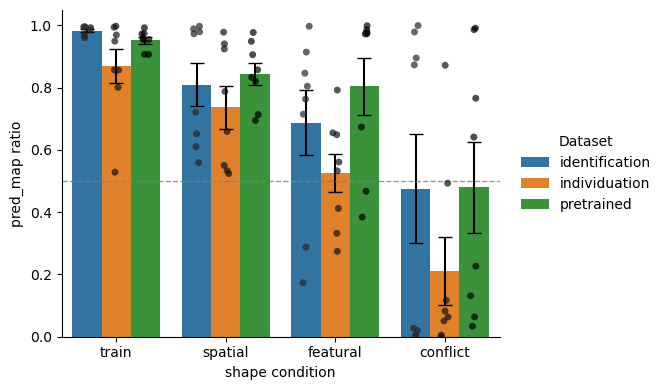

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# =========================
# CONFIG
# =========================
CSV_1 = "/zpool/vladlab/active_drive/omaltz/scripts/geogaze/coco_decoder/v2/identification/results/geogaze_model_predictions_identification_pred_avg_ratio_stimuli_same_color.csv"
CSV_2 = "/zpool/vladlab/active_drive/omaltz/scripts/geogaze/coco_decoder/v2/individuation/results/geogaze_model_predictions_individuation_pred_avg_ratio_stimuli_same_color.csv"
CSV_3 = "/zpool/vladlab/active_drive/omaltz/scripts/geogaze/coco_decoder/v2/pretrained/geogaze_model_predictions_pretrained_pred_avg_ratio_stimuli_same_color.csv" 
COND_ORDER = ["train", "spatial", "featural", "conflict"]

# =========================
# LOAD
# =========================
df1 = pd.read_csv(CSV_1); df1["dataset"] = "identification"
df2 = pd.read_csv(CSV_2); df2["dataset"] = "individuation"
df3 = pd.read_csv(CSV_3); df3["dataset"] = "pretrained"  # <-- rename label if you want

df = pd.concat([df1, df2, df3], ignore_index=True)

# =========================
# WITHIN-MODEL COLLAPSE
# =========================
df_collapsed = (
    df.groupby(["dataset", "model", "condition"], as_index=False)
      .agg(ratio=("ratio", "mean"))
)

df_collapsed["condition"] = pd.Categorical(
    df_collapsed["condition"],
    categories=COND_ORDER,
    ordered=True
)

# =========================
# SUMMARY STATS (MEAN + SEM)
# =========================
summary = (
    df_collapsed.groupby(["dataset", "condition"], as_index=False)
      .agg(
          mean_ratio=("ratio", "mean"),
          sd_ratio=("ratio", "std"),
          n_models=("ratio", "count")
      )
)
summary["sem_ratio"] = summary["sd_ratio"] / np.sqrt(summary["n_models"])

# =========================
# PLOT
# =========================
plt.figure(figsize=(8, 4))
ax = sns.barplot(
    data=summary,
    x="condition",
    y="mean_ratio",
    hue="dataset",
    order=COND_ORDER,
    dodge=True,
    errorbar=None
)

# ---- SEM error bars (computed to match seaborn's dodge positions) ----
hue_order = list(summary["dataset"].dropna().unique())
n_hue = len(hue_order)

# width seaborn uses for a single bar "slot" is ~0.8 of the category width
group_width = 0.8
bar_width = group_width / max(n_hue, 1)

for _, row in summary.iterrows():
    cond_i = COND_ORDER.index(row["condition"])
    hue_i = hue_order.index(row["dataset"])

    # center bars within category slot
    x_pos = cond_i - group_width / 2 + bar_width / 2 + hue_i * bar_width

    ax.errorbar(
        x=x_pos,
        y=row["mean_ratio"],
        yerr=row["sem_ratio"],
        fmt="none",
        capsize=5,
        linewidth=1.5,
        color="black"
    )

# ---- Individual model points (black dots) ----
sns.stripplot(
    data=df_collapsed,
    x="condition",
    y="ratio",
    hue="dataset",
    order=COND_ORDER,
    dodge=True,
    jitter=True,
    color="black",
    alpha=0.7,
    size=5,
    ax=ax
)

# ---- Reference line ----
ax.axhline(y=0.5, linestyle="--", linewidth=1, color="gray", alpha=0.8)

# =========================
# LEGEND OUTSIDE (dedupe barplot + stripplot legends)
# =========================
handles, labels = ax.get_legend_handles_labels()
ax.legend(
    handles[:n_hue],
    labels[:n_hue],
    title="Dataset",
    frameon=False,
    loc="center left",
    bbox_to_anchor=(1.02, 0.5)
)

# =========================
# LABELS & CLEANUP
# =========================
ax.set_ylabel("pred_map ratio")
ax.set_xlabel("shape condition")
sns.despine()
plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.show()


/tmp/ipykernel_4055825/1602882198.py:41: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_collapsed.groupby(["dataset", "condition"], as_index=False)
/tmp/ipykernel_4055825/1602882198.py:90: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(


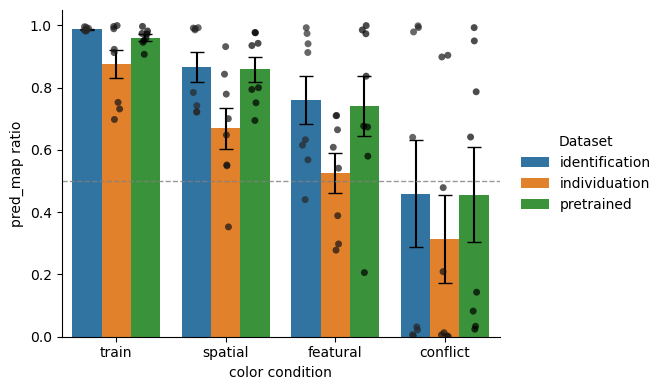

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# =========================
# CONFIG
# =========================
CSV_1 = "/zpool/vladlab/active_drive/omaltz/scripts/geogaze/coco_decoder/v2/identification/results/geogaze_model_predictions_identification_pred_avg_ratio_stimuli_same_shape.csv"
CSV_2 = "/zpool/vladlab/active_drive/omaltz/scripts/geogaze/coco_decoder/v2/individuation/results/geogaze_model_predictions_individuation_pred_avg_ratio_stimuli_same_shape.csv"
CSV_3 = "/zpool/vladlab/active_drive/omaltz/scripts/geogaze/coco_decoder/v2/pretrained/geogaze_model_predictions_pretrained_pred_avg_ratio_stimuli_same_shape.csv" 
COND_ORDER = ["train", "spatial", "featural", "conflict"]

# =========================
# LOAD
# =========================
df1 = pd.read_csv(CSV_1); df1["dataset"] = "identification"
df2 = pd.read_csv(CSV_2); df2["dataset"] = "individuation"
df3 = pd.read_csv(CSV_3); df3["dataset"] = "pretrained"  # <-- rename label if you want

df = pd.concat([df1, df2, df3], ignore_index=True)

# =========================
# WITHIN-MODEL COLLAPSE
# =========================
df_collapsed = (
    df.groupby(["dataset", "model", "condition"], as_index=False)
      .agg(ratio=("ratio", "mean"))
)

df_collapsed["condition"] = pd.Categorical(
    df_collapsed["condition"],
    categories=COND_ORDER,
    ordered=True
)

# =========================
# SUMMARY STATS (MEAN + SEM)
# =========================
summary = (
    df_collapsed.groupby(["dataset", "condition"], as_index=False)
      .agg(
          mean_ratio=("ratio", "mean"),
          sd_ratio=("ratio", "std"),
          n_models=("ratio", "count")
      )
)
summary["sem_ratio"] = summary["sd_ratio"] / np.sqrt(summary["n_models"])

# =========================
# PLOT
# =========================
plt.figure(figsize=(8, 4))
ax = sns.barplot(
    data=summary,
    x="condition",
    y="mean_ratio",
    hue="dataset",
    order=COND_ORDER,
    dodge=True,
    errorbar=None
)

# ---- SEM error bars (computed to match seaborn's dodge positions) ----
hue_order = list(summary["dataset"].dropna().unique())
n_hue = len(hue_order)

# width seaborn uses for a single bar "slot" is ~0.8 of the category width
group_width = 0.8
bar_width = group_width / max(n_hue, 1)

for _, row in summary.iterrows():
    cond_i = COND_ORDER.index(row["condition"])
    hue_i = hue_order.index(row["dataset"])

    # center bars within category slot
    x_pos = cond_i - group_width / 2 + bar_width / 2 + hue_i * bar_width

    ax.errorbar(
        x=x_pos,
        y=row["mean_ratio"],
        yerr=row["sem_ratio"],
        fmt="none",
        capsize=5,
        linewidth=1.5,
        color="black"
    )

# ---- Individual model points (black dots) ----
sns.stripplot(
    data=df_collapsed,
    x="condition",
    y="ratio",
    hue="dataset",
    order=COND_ORDER,
    dodge=True,
    jitter=True,
    color="black",
    alpha=0.7,
    size=5,
    ax=ax
)

# ---- Reference line ----
ax.axhline(y=0.5, linestyle="--", linewidth=1, color="gray", alpha=0.8)

# =========================
# LEGEND OUTSIDE (dedupe barplot + stripplot legends)
# =========================
handles, labels = ax.get_legend_handles_labels()
ax.legend(
    handles[:n_hue],
    labels[:n_hue],
    title="Dataset",
    frameon=False,
    loc="center left",
    bbox_to_anchor=(1.02, 0.5)
)

# =========================
# LABELS & CLEANUP
# =========================
ax.set_ylabel("pred_map ratio")
ax.set_xlabel("color condition")
sns.despine()
plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.show()


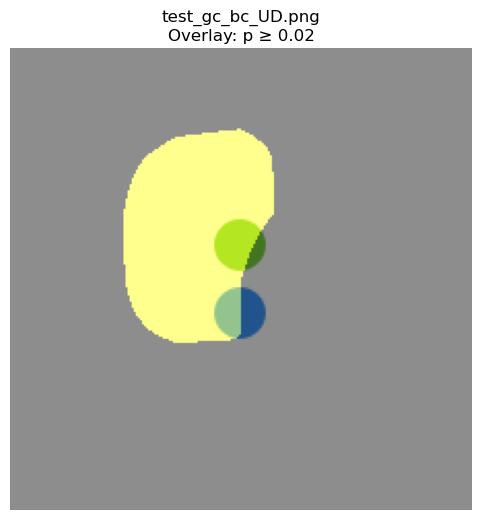

In [56]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

# =========================
# EDIT THESE
# =========================
IMAGE_PATH = Path("/zpool/vladlab/data_drive/geogaze_data/cornetz_coco/v2/individuation/test_images/cornetIDIV_maskL_bc_gc/test_gc_bc_UD.png")
PROB_CSV_PATH = Path("/zpool/vladlab/active_drive/omaltz/scripts/geogaze/coco_decoder/v2/individuation/best_model_outputs/cornetIDIV_maskL_bc_gc/test_gc_bc_UD_prob_map.csv")
THRESH = 0.02
# =========================


img = Image.open(IMAGE_PATH).convert("RGB")
img_arr = np.array(img)

prob_df = pd.read_csv(PROB_CSV_PATH, header=0)
prob_arr = prob_df.to_numpy()

if prob_arr.shape[:2] != img_arr.shape[:2]:
    raise ValueError(
        f"Shape mismatch!\n"
        f"Image shape: {img_arr.shape[:2]}\n"
        f"Prob map shape: {prob_arr.shape}"
    )

high_prob = prob_arr >= THRESH

overlay = np.zeros_like(img_arr)
overlay[..., 0] = high_prob * 255   
overlay[..., 1] = high_prob * 255   
overlay[..., 2] = 0                 

plt.figure(figsize=(6, 6))
plt.imshow(img_arr)
plt.imshow(overlay, alpha=0.45)
plt.axis("off")
plt.title(
    f"{IMAGE_PATH.name}\nOverlay: p ≥ {THRESH}"
)
plt.show()
